In [1]:
# --- Importações Essenciais ---
import os
import numpy as np
import pandas as pd
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns

# --- Importações do Scikit-learn ---
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.ensemble import RandomForestClassifier 
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from scipy import sparse
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    precision_recall_curve,
    auc,
    roc_curve,
    average_precision_score
)

# --- Configurações de Visualização ---
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- Funções Auxiliares ---
def calculate_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    if (tn + fp) == 0:
        return 1.0
    return tn / (tn + fp)

print("Bibliotecas importadas e configurações aplicadas.")

Bibliotecas importadas e configurações aplicadas.


In [2]:
# Definir o caminho para os dados processados
processed_data_path = '../../data/processed/cidds_dataset'
train_proc_path = os.path.join(processed_data_path, 'train_processed.npz')
test_proc_path = os.path.join(processed_data_path, 'test_processed.npz')

# Carregar os arrays NumPy
train_data = np.load(train_proc_path, allow_pickle=True)
test_data = np.load(test_proc_path, allow_pickle=True)
X_test = test_data['X'].item()
y_test = test_data['y']
X_full = train_data['X'].item()
y_full = train_data['y']

print(f"Formato do dataset completo (X): {X_full.shape}")
print(f"Formato do dataset completo (y): {y_full.shape}")
print("---")

# **Divisão Estratégica em Treino, Validação e Teste**
X_train, X_val, y_train, y_val = train_test_split(
    X_full,
    y_full,
    test_size=(1/7),
    random_state=42,
    stratify=y_full
)

# Verificar as dimensões finais
print("Divisão final dos dados:")
print(f"Treino (X, y):    \t{X_train.shape}, {y_train.shape}")
print(f"Validação (X, y): \t{X_val.shape}, {y_val.shape}")
print(f"Teste (X, y):     \t{X_test.shape}, {y_test.shape}")

X_train_pca = X_train
X_val_pca   = X_val
X_test_pca  = X_test

Formato do dataset completo (X): (95029, 294)
Formato do dataset completo (y): (95029,)
---
Divisão final dos dados:
Treino (X, y):    	(81453, 294), (81453,)
Validação (X, y): 	(13576, 294), (13576,)
Teste (X, y):     	(56303, 294), (56303,)


In [3]:
# Para o tuning, vamos usar uma pequena porção dos dados de treino como se fossem
# os únicos dados rotulados disponíveis, para encontrar o melhor "expert".
label_proportion = 0.10 # Usaremos 10% dos rótulos para o tuning
print(f"--- Separando {label_proportion:.0%} dos dados de treino para o tuning do modelo base ---")

X_train_labeled, _, y_train_labeled, _ = train_test_split(
    X_train,
    y_train,
    train_size=label_proportion,
    random_state=42,
    stratify=y_train
)

print(f"Formato dos dados rotulados (antes do SMOTE): {X_train_labeled.shape}")
print(f"Distribuição dos rótulos (antes do SMOTE): {pd.Series(y_train_labeled).value_counts().to_dict()}")

# Aplicando o SMOTE na fração dos dados
print("\n--- Balanceando o pequeno conjunto de dados rotulados com SMOTE ---")
smote = SMOTE(random_state=42)
X_train_labeled_bal, y_train_labeled_bal = smote.fit_resample(X_train_labeled, y_train_labeled)

print(f"Formato dos dados rotulados (depois do SMOTE): {X_train_labeled_bal.shape}")
print(f"Distribuição dos rótulos (depois do SMOTE): {pd.Series(y_train_labeled_bal).value_counts().to_dict()}")

--- Separando 10% dos dados de treino para o tuning do modelo base ---
Formato dos dados rotulados (antes do SMOTE): (8145, 294)
Distribuição dos rótulos (antes do SMOTE): {1: 6022, 0: 2123}

--- Balanceando o pequeno conjunto de dados rotulados com SMOTE ---
Formato dos dados rotulados (depois do SMOTE): (12044, 294)
Distribuição dos rótulos (depois do SMOTE): {1: 6022, 0: 6022}


In [4]:
# Grade de hiperparâmetros a ser explorada para o RandomForest (modelo base)
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 5]
}

# Número de repetições para cada combinação
n_repeats = 5

# Lista para armazenar os resultados
results_list = []

print("Grade de parâmetros do RandomForest definida.")

Grade de parâmetros do RandomForest definida.


In [5]:
total_runs = len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_leaf'] * n_repeats)
current_run = 0

print(f"Iniciando a busca em grade para o RandomForest base... Total de {total_runs} execuções.")

for n_est in param_grid['n_estimators']:
    for m_depth in param_grid['max_depth']:
        for m_leaf in param_grid['min_samples_leaf']:
            for x in range(n_repeats):
                current_run += 1
                print(f"Execução {current_run}/{total_runs}: n_est={n_est}, max_depth={m_depth}, min_leaf={m_leaf}")
    
                model = RandomForestClassifier(
                    n_estimators=n_est,
                    max_depth=m_depth,
                    min_samples_leaf=m_leaf,
                    random_state=42,
                    n_jobs=-1
                )
    
                start_time = time.time()
                model.fit(X_train_labeled_bal, y_train_labeled_bal)
                train_time = time.time() - start_time
    
                y_pred_val = model.predict(X_val_pca)
                y_probs_val_loop = model.predict_proba(X_val_pca)[:, 1]
    
                results_list.append({
                    'n_estimators': n_est, 'max_depth': m_depth, 'min_samples_leaf': m_leaf,
                    'train_time': train_time,
                    'f1_score': f1_score(y_val, y_pred_val),
                    'roc_auc': roc_auc_score(y_val, y_probs_val_loop)
                })

print("\nBusca em grade concluída!")

Iniciando a busca em grade para o RandomForest base... Total de 90 execuções.
Execução 1/90: n_est=50, max_depth=10, min_leaf=1
Execução 2/90: n_est=50, max_depth=10, min_leaf=1
Execução 3/90: n_est=50, max_depth=10, min_leaf=1
Execução 4/90: n_est=50, max_depth=10, min_leaf=1
Execução 5/90: n_est=50, max_depth=10, min_leaf=1
Execução 6/90: n_est=50, max_depth=10, min_leaf=5
Execução 7/90: n_est=50, max_depth=10, min_leaf=5
Execução 8/90: n_est=50, max_depth=10, min_leaf=5
Execução 9/90: n_est=50, max_depth=10, min_leaf=5
Execução 10/90: n_est=50, max_depth=10, min_leaf=5
Execução 11/90: n_est=50, max_depth=20, min_leaf=1
Execução 12/90: n_est=50, max_depth=20, min_leaf=1
Execução 13/90: n_est=50, max_depth=20, min_leaf=1
Execução 14/90: n_est=50, max_depth=20, min_leaf=1
Execução 15/90: n_est=50, max_depth=20, min_leaf=1
Execução 16/90: n_est=50, max_depth=20, min_leaf=5
Execução 17/90: n_est=50, max_depth=20, min_leaf=5
Execução 18/90: n_est=50, max_depth=20, min_leaf=5
Execução 19/9

In [6]:
results_df = pd.DataFrame(results_list)
results_df.to_csv('../../reports/cidds_reports/selftraining_rf_tuning_detailed.csv', index=False)
agg_results_df = results_df.groupby(['n_estimators', 'max_depth', 'min_samples_leaf']).mean().reset_index()
agg_results_df['composite_score'] = (agg_results_df['f1_score'] + agg_results_df['roc_auc']) / 2
best_params = agg_results_df.sort_values(by='composite_score', ascending=False).iloc[0]

print("--- Melhores Hiperparâmetros para o RandomForest Base Encontrados ---")
print(best_params)

agg_results_df.to_csv('../../reports/cidds_reports/selftraining_rf_tuning_aggregated.csv', index=False)

--- Melhores Hiperparâmetros para o RandomForest Base Encontrados ---
n_estimators        50.000000
max_depth           10.000000
min_samples_leaf     1.000000
train_time           0.097541
f1_score             1.000000
roc_auc              1.000000
composite_score      1.000000
Name: 0, dtype: float64


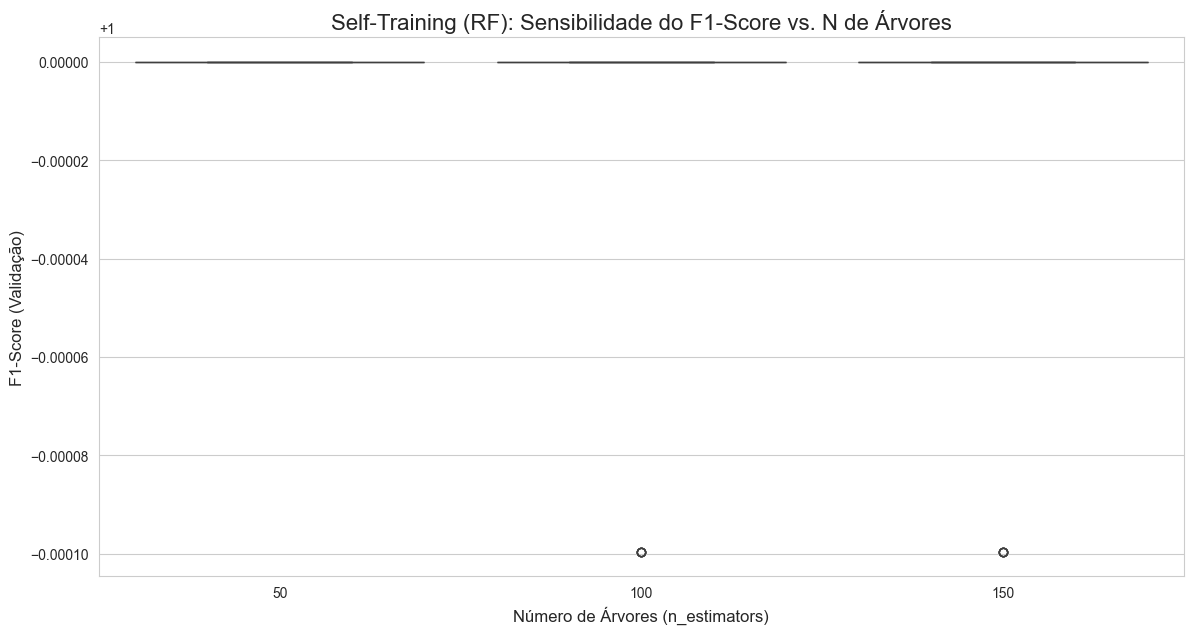

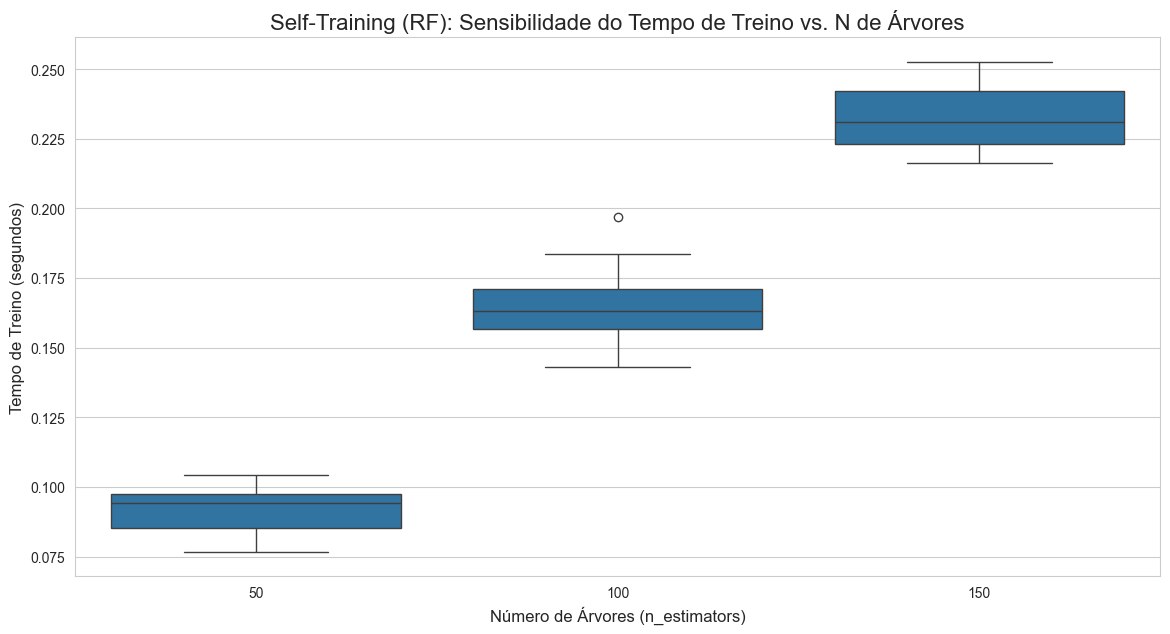

In [7]:
plt.figure(figsize=(14, 7))
sns.boxplot(x='n_estimators', y='f1_score', data=results_df)
plt.title('Self-Training (RF): Sensibilidade do F1-Score vs. N de Árvores', fontsize=16)
plt.xlabel('Número de Árvores (n_estimators)', fontsize=12)
plt.ylabel('F1-Score (Validação)', fontsize=12)
plt.show()

plt.figure(figsize=(14, 7))
sns.boxplot(x='n_estimators', y='train_time', data=results_df)
plt.title('Self-Training (RF): Sensibilidade do Tempo de Treino vs. N de Árvores', fontsize=16)
plt.xlabel('Número de Árvores (n_estimators)', fontsize=12)
plt.ylabel('Tempo de Treino (segundos)', fontsize=12)
plt.show()

--- Otimização do Limiar de Decisão com SelfTrainingClassifier (Validation Set) ---
Distribuição de rótulos para treino: {-1: 73308, 1: 6022, 0: 2123}
End of iteration 1, added 72937 new labels.
End of iteration 2, added 109 new labels.
End of iteration 3, added 48 new labels.
End of iteration 4, added 4 new labels.
End of iteration 5, added 31 new labels.
End of iteration 6, added 13 new labels.

Melhor Limiar de Decisão encontrado: 0.5972


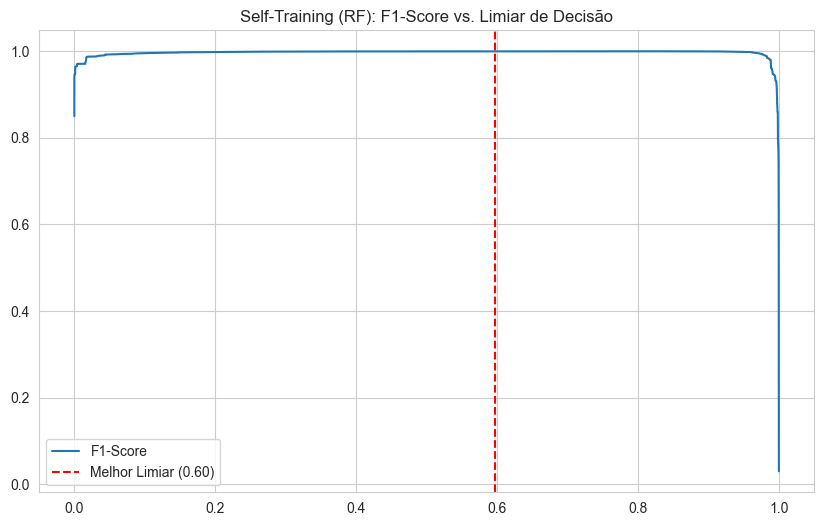

In [8]:
print("--- Otimização do Limiar de Decisão com SelfTrainingClassifier (Validation Set) ---")

# Preparar os dados de treino para o formato semi-supervisionado (-1 para não rotulados)
y_train_semi = np.copy(y_train)
# Recriar a máscara de rótulos aqui, pois a variável original era de outra célula
labels_to_keep_indices, _ = train_test_split(
    np.arange(len(y_train)), train_size=label_proportion, random_state=42, stratify=y_train
)
unlabeled_mask = ~np.isin(np.arange(len(y_train)), labels_to_keep_indices)
y_train_semi[unlabeled_mask] = -1
print(f"Distribuição de rótulos para treino: {pd.Series(y_train_semi).value_counts().to_dict()}")

# 1. Instanciar o modelo base (expert) com os melhores hiperparâmetros
final_max_depth = best_params['max_depth']
if pd.isna(final_max_depth): final_max_depth = None
    
base_classifier = RandomForestClassifier(
    n_estimators=int(best_params['n_estimators']),
    max_depth=None if pd.isna(best_params['max_depth']) else int(best_params['max_depth']),
    min_samples_leaf=int(best_params['min_samples_leaf']),
    random_state=42,
    n_jobs=-1
)

# 2. Envolver o modelo base com o SelfTrainingClassifier
model_for_tuning = SelfTrainingClassifier(
    estimator=base_classifier,
    threshold=0.9,  # Confiança mínima para criar um pseudo-rótulo (ajustável)
    verbose=True
)

# 3. Treinar o modelo semi-supervisionado
model_for_tuning.fit(X_train_pca, y_train_semi)

# 4. Obter probabilidades no conjunto de validação para encontrar o limiar
y_probs_val = model_for_tuning.predict_proba(X_val_pca)[:, 1]

# Lógica para encontrar o melhor limiar de decisão
precision, recall, thresholds = precision_recall_curve(y_val, y_probs_val)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]

print(f"\nMelhor Limiar de Decisão encontrado: {best_threshold:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.title("Self-Training (RF): F1-Score vs. Limiar de Decisão")
plt.axvline(best_threshold, color='r', linestyle='--', label=f'Melhor Limiar ({best_threshold:.2f})')
plt.legend()
plt.show()

Distribuição final para treino: {-1: 85527, 1: 7025, 0: 2477}

Treinando o modelo final Self-Training (RandomForest)...
End of iteration 1, added 84644 new labels.
End of iteration 2, added 268 new labels.
End of iteration 3, added 75 new labels.
End of iteration 4, added 30 new labels.
End of iteration 5, added 11 new labels.
End of iteration 6, added 62 new labels.
End of iteration 7, added 7 new labels.
End of iteration 8, added 52 new labels.
End of iteration 9, added 13 new labels.
End of iteration 10, added 33 new labels.
Treino concluído.

--- Relatório de Classificação Final com Limiar Otimizado (Conjunto de Teste) ---
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00     24780
    Anomalia       0.56      1.00      0.72     31523

    accuracy                           0.56     56303
   macro avg       0.28      0.50      0.36     56303
weighted avg       0.31      0.56      0.40     56303


ROC AUC (Teste): 0.9925
--- Matriz de

C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\GabrielMoreira\log-anomaly-detection-ml\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

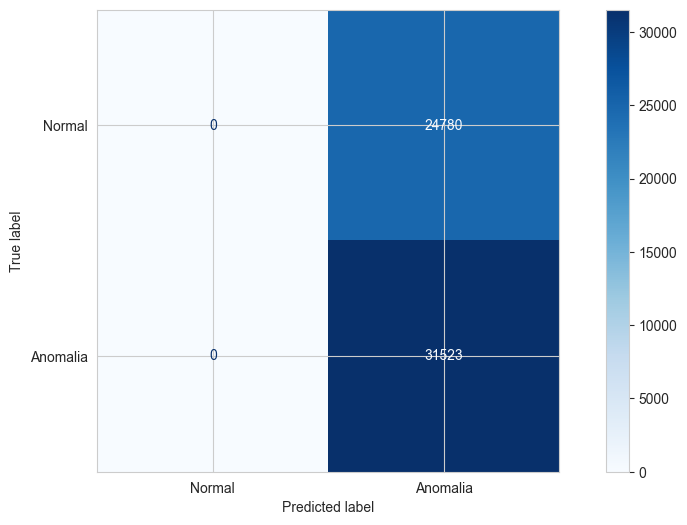

In [9]:
# Combinar dados de treino e validação
X_train_full = sparse.vstack((X_train, X_val))
y_train_full = np.concatenate((y_train, y_val))

# Preparar o conjunto final de treino semi-supervisionado (-1 para não rotulados)
y_train_full_semi = np.copy(y_train_full)
final_labels_to_keep_indices, _ = train_test_split(
    np.arange(len(y_train_full)), train_size=label_proportion, random_state=42, stratify=y_train_full
)
final_unlabeled_mask = ~np.isin(np.arange(len(y_train_full)), final_labels_to_keep_indices)
y_train_full_semi[final_unlabeled_mask] = -1
print("Distribuição final para treino:", pd.Series(y_train_full_semi).value_counts().to_dict())

# Instanciar o modelo base final com os melhores hiperparâmetros
final_base_classifier = RandomForestClassifier(
    n_estimators=int(best_params['n_estimators']),
    max_depth=None if pd.isna(best_params['max_depth']) else int(best_params['max_depth']),
    min_samples_leaf=int(best_params['min_samples_leaf']),
    random_state=42,
    n_jobs=-1
)

# Instanciar o classificador semi-supervisionado final
final_model = SelfTrainingClassifier(
    estimator=final_base_classifier,
    threshold=0.9,
    verbose=True
)

# Treinar o modelo final
print("\nTreinando o modelo final Self-Training (RandomForest)...")
final_model.fit(X_train_full, y_train_full_semi)
print("Treino concluído.")

# Fazer previsões no conjunto de teste
y_pred_test_probs = final_model.predict_proba(X_test_pca)[:, 1]
y_pred_test_tuned = (y_pred_test_probs >= best_threshold).astype(int)

# Avaliar o desempenho final
print("\n--- Relatório de Classificação Final com Limiar Otimizado (Conjunto de Teste) ---")
print(classification_report(y_test, y_pred_test_tuned, target_names=['Normal', 'Anomalia']))

# Métricas no conjunto de teste
roc_auc_test = roc_auc_score(y_test, y_pred_test_probs)
print(f"\nROC AUC (Teste): {roc_auc_test:.4f}")

# Visualizar a Matriz de Confusão
print("--- Matriz de Confusão com Limiar Otimizado (Conjunto de Teste) ---")
cm_tuned = confusion_matrix(y_test, y_pred_test_tuned)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['Normal', 'Anomalia'])
disp_tuned.plot(cmap=plt.cm.Blues)
plt.show()